### 1. Import libraries

In [ ]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Set device and reproducibility

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 3. Dataset import from folders

In [ ]:
DATA_DIR = "/content/drive/MyDrive/Data_A2"

class_names = ["algal leaf", "brown blight", "white spot"]

for cls in class_names:
    folder_path = os.path.join(DATA_DIR, cls)
    print(cls, ":", len(os.listdir(folder_path)), "images")

algal leaf : 113 images
brown blight : 113 images
white spot : 142 images


### 4. Image transformations

In [ ]:
image_size = 224
batch_size = 16

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 5. Load dataset and split into train / validation / test

In [ ]:
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)

print("Classes:", full_dataset.classes)
print("Class to index:", full_dataset.class_to_idx)
print("Total images:", len(full_dataset))

Classes: ['algal leaf', 'brown blight', 'white spot']
Class to index: {'algal leaf': 0, 'brown blight': 1, 'white spot': 2}
Total images: 368


Split: 70% train, 15% validation, 15% test.

In [ ]:
total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Validation and test should not use augmentation
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

dataloaders = {
    "train": train_loader,
    "val": val_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset)
}

print(dataset_sizes)

{'train': 257, 'val': 55, 'test': 56}


### 6. Visualize sample images

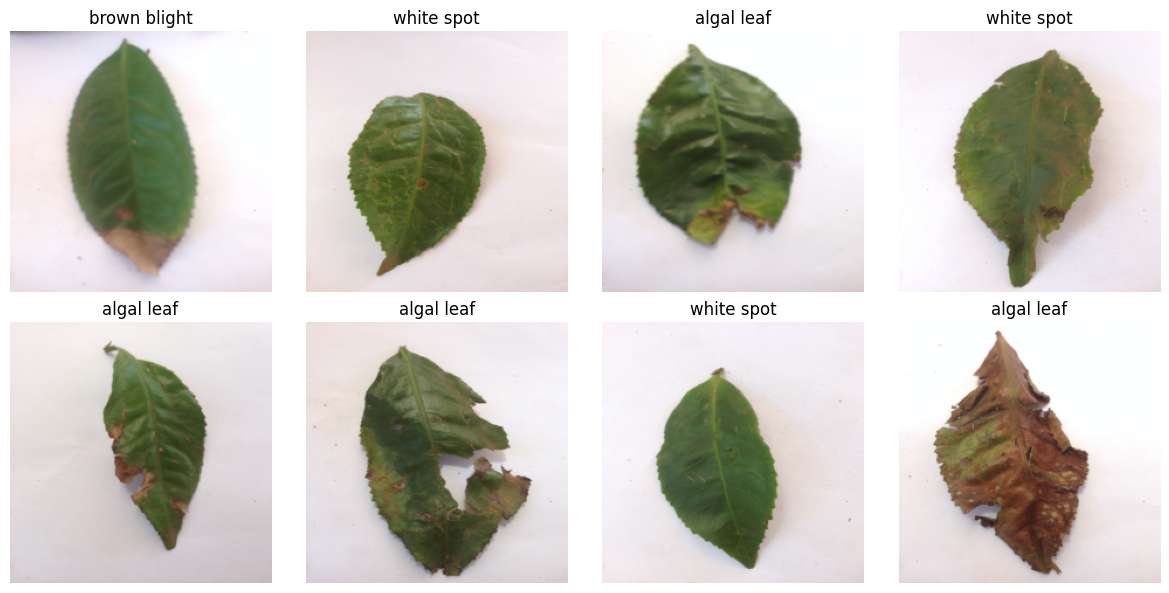

In [ ]:
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")


inputs, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(inputs))):
    plt.subplot(2, 4, i + 1)
    imshow(inputs[i], title=full_dataset.classes[labels[i]])
plt.tight_layout()
plt.show()

### 7. Training function

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 30)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f"Training completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

### 8. Build VGG16 transfer learning model

In [ ]:
def create_vgg16_model(num_classes):
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # Freeze feature extractor layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace final classifier layer
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    return model.to(device)

### 9. Train VGG16

In [ ]:
num_classes = len(full_dataset.classes)
num_epochs = 10
learning_rate = 0.001

vgg_model = create_vgg16_model(num_classes)

criterion = nn.CrossEntropyLoss()
vgg_optimizer = optim.Adam(vgg_model.parameters(), lr=learning_rate)

vgg_model, vgg_history = train_model(
    vgg_model,
    criterion,
    vgg_optimizer,
    num_epochs=num_epochs
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:16<00:00, 34.2MB/s]


Epoch 1/10
------------------------------
train Loss: 2.0218 Acc: 0.4086
val Loss: 2.3208 Acc: 0.3818

Epoch 2/10
------------------------------
train Loss: 1.0381 Acc: 0.6226
val Loss: 0.5422 Acc: 0.7818

Epoch 3/10
------------------------------
train Loss: 0.4260 Acc: 0.8327
val Loss: 0.5007 Acc: 0.8545

Epoch 4/10
------------------------------
train Loss: 0.2316 Acc: 0.9183
val Loss: 2.0919 Acc: 0.5636

Epoch 5/10
------------------------------
train Loss: 0.1860 Acc: 0.9533
val Loss: 1.1771 Acc: 0.7636

Epoch 6/10
------------------------------
train Loss: 0.2400 Acc: 0.9494
val Loss: 1.8386 Acc: 0.7273

Epoch 7/10
------------------------------
train Loss: 0.2834 Acc: 0.9572
val Loss: 3.5890 Acc: 0.7091

Epoch 8/10
------------------------------
train Loss: 0.5576 Acc: 0.9300
val Loss: 1.2349 Acc: 0.8727

Epoch 9/10
------------------------------
train Loss: 0.7559 Acc: 0.9183
val Loss: 11.3901 Acc: 0.4545

Epoch 10/10
------------------------------
train Loss: 1.1850 Acc: 0.914

### 10. Build ResNet50 transfer learning model

In [ ]:
def create_resnet50_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace final fully connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model.to(device)

### 11. Train ResNet50

In [ ]:
resnet_model = create_resnet50_model(num_classes)

criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)

resnet_model, resnet_history = train_model(
    resnet_model,
    criterion,
    resnet_optimizer,
    num_epochs=num_epochs
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 59.8MB/s]


Epoch 1/10
------------------------------
train Loss: 1.0768 Acc: 0.4086
val Loss: 1.0276 Acc: 0.4727

Epoch 2/10
------------------------------
train Loss: 0.9425 Acc: 0.6498
val Loss: 1.0066 Acc: 0.5273

Epoch 3/10
------------------------------
train Loss: 0.8576 Acc: 0.7704
val Loss: 0.9276 Acc: 0.6182

Epoch 4/10
------------------------------
train Loss: 0.7888 Acc: 0.8132
val Loss: 0.8576 Acc: 0.7091

Epoch 5/10
------------------------------
train Loss: 0.7244 Acc: 0.8599
val Loss: 0.8276 Acc: 0.7818

Epoch 6/10
------------------------------
train Loss: 0.6553 Acc: 0.8794
val Loss: 0.7642 Acc: 0.7636

Epoch 7/10
------------------------------
train Loss: 0.6255 Acc: 0.8755
val Loss: 0.7901 Acc: 0.7636

Epoch 8/10
------------------------------
train Loss: 0.5931 Acc: 0.8833
val Loss: 0.7493 Acc: 0.7636

Epoch 9/10
------------------------------
train Loss: 0.5526 Acc: 0.8833
val Loss: 0.6653 Acc: 0.7818

Epoch 10/10
------------------------------
train Loss: 0.5589 Acc: 0.8833

Save VGG16

In [ ]:
torch.save(vgg_model.state_dict(), "vgg16_tea_leaf_model.pth")

Save ResNet50

In [ ]:
torch.save(resnet_model.state_dict(), "resnet50_tea_leaf_model.pth")

### 12. Plot accuracy and loss comparison

In [ ]:
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

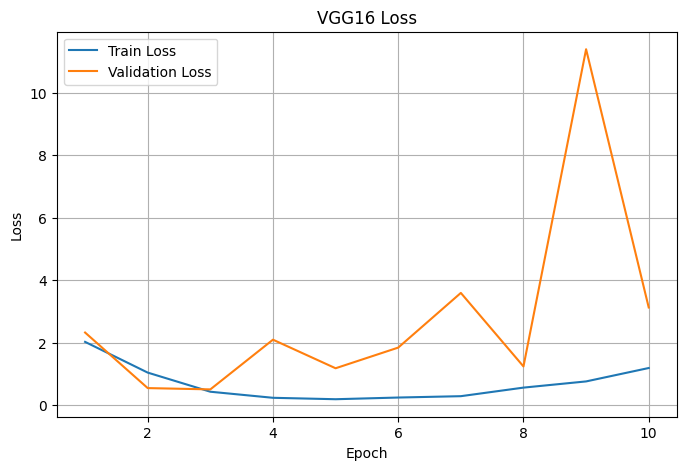

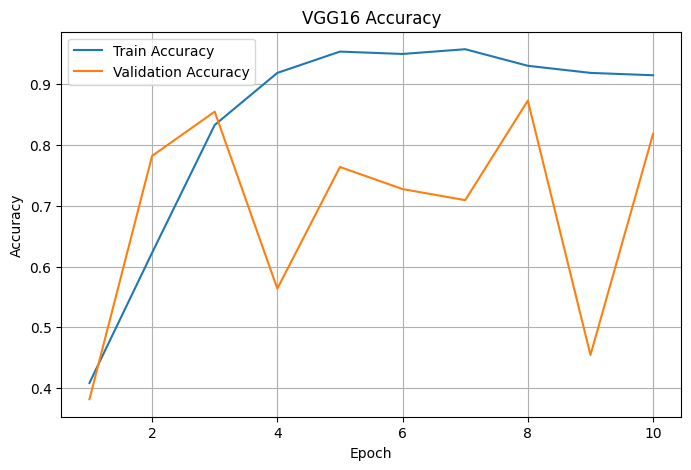

In [ ]:
plot_history(vgg_history, "VGG16")

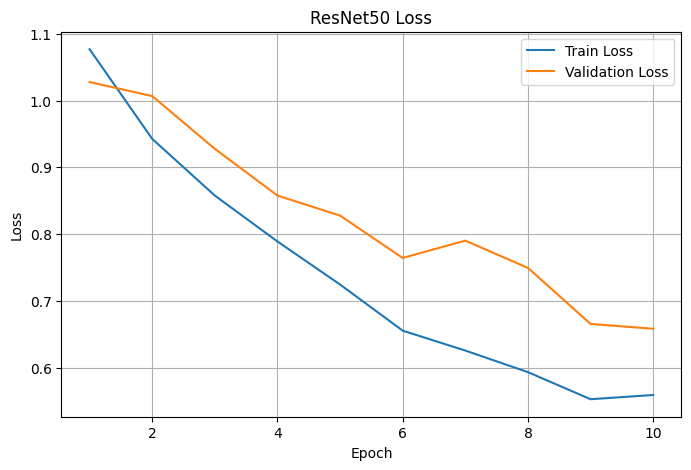

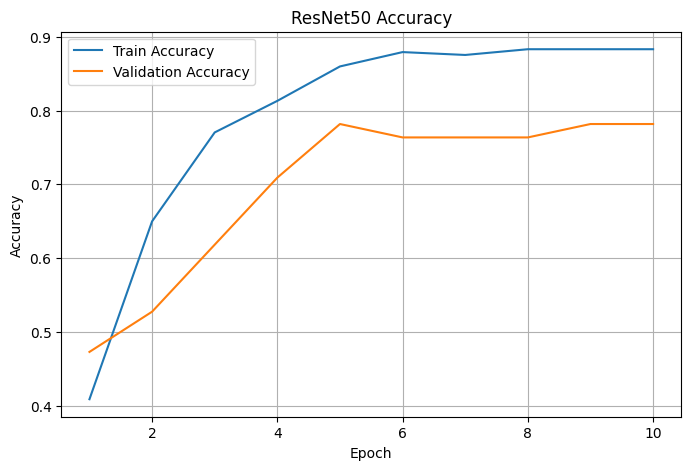

In [ ]:
plot_history(resnet_history, "ResNet50")

### 13. Evaluate model on test data

In [ ]:
def evaluate_model(model, test_loader, class_names):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = accuracy_score(all_labels, all_preds)

    print("Test Accuracy:", test_acc)
    print()
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return test_acc

Test Accuracy: 0.8392857142857143

Classification Report:
              precision    recall  f1-score   support

  algal leaf       0.72      0.87      0.79        15
brown blight       0.76      0.81      0.79        16
  white spot       1.00      0.84      0.91        25

    accuracy                           0.84        56
   macro avg       0.83      0.84      0.83        56
weighted avg       0.86      0.84      0.84        56



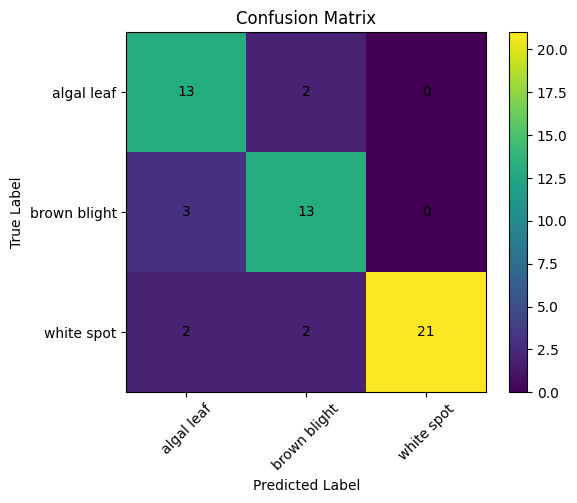

In [ ]:
vgg_test_acc = evaluate_model(vgg_model, test_loader, full_dataset.classes)

Test Accuracy: 0.6607142857142857

Classification Report:
              precision    recall  f1-score   support

  algal leaf       0.75      0.60      0.67        15
brown blight       0.56      0.56      0.56        16
  white spot       0.68      0.76      0.72        25

    accuracy                           0.66        56
   macro avg       0.66      0.64      0.65        56
weighted avg       0.66      0.66      0.66        56



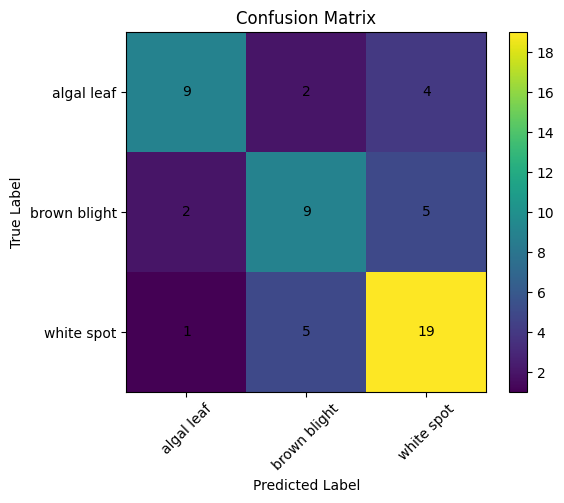

In [ ]:
resnet_test_acc = evaluate_model(resnet_model, test_loader, full_dataset.classes)

### 14. Create comparison table

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["VGG16", "ResNet50"],
    "Best Validation Accuracy": [
        max(vgg_history["val_acc"]),
        max(resnet_history["val_acc"])
    ],
    "Final Validation Loss": [
        vgg_history["val_loss"][-1],
        resnet_history["val_loss"][-1]
    ],
    "Test Accuracy": [
        vgg_test_acc,
        resnet_test_acc
    ]
})

comparison_df

,Model,Best Validation Accuracy,Final Validation Loss,Test Accuracy
0,VGG16,0.872727,3.123021,0.839286
1,ResNet50,0.781818,0.658160,0.660714


### 15. Bar chart for model comparison

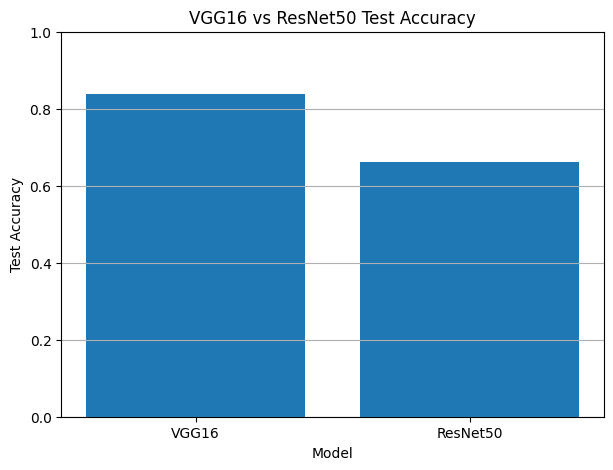

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("VGG16 vs ResNet50 Test Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

### 16. Predict a single new image

In [ ]:
from PIL import Image

def predict_image(image_path, model, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    predicted_label = class_names[predicted_class.item()]
    confidence_value = confidence.item()

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_label} ({confidence_value:.2f})")
    plt.show()

    return predicted_label, confidence_value